# Project Statement

The Film Junky Union, a new edgy community for classic movie enthusiasts, is developing a system for filtering and categorizing movie reviews. The goal is to train a model to automatically detect negative reviews. You'll be using a dataset of IMBD movie reviews with polarity labelling to build a model for classifying positive and negative reviews. It will need to have an F1 score of at least 0.85.

## Initialization

In [1]:
import math

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
# the next line provides graphs of better quality on HiDPI screens
%config InlineBackend.figure_format = 'retina'

plt.style.use('seaborn')

In [3]:
# this is to use progress_apply, read more at https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()

## Load Data

In [4]:
df_reviews = pd.read_csv('imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})

In [5]:
df_reviews.info()
df_reviews.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331 non-null  int64  
dtypes: Int64(1),

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281


In [6]:
df_reviews.isna().sum()

tconst             0
title_type         0
primary_title      0
original_title     0
start_year         0
end_year           0
runtime_minutes    0
is_adult           0
genres             0
average_rating     2
votes              2
review             0
rating             0
sp                 0
pos                0
ds_part            0
idx                0
dtype: int64

**🗣️ Data Loading:**

I began by loading the IMDB reviews dataset using df_reviews = pd.read_csv('/datasets/imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'}). Since the file is tab-separated (.tsv), I used sep='\t' to ensure it was parsed correctly. I also specified the votes column as Int64 so it could hold missing values without type errors.

After loading, I inspected the dataset with .info() and .head(). The dataset contains 47,331 rows across columns like tconst, title_type, primary_title, start_year, genres, review, and pos (the sentiment label). Each row represents a single review, not a single movie — a given tconst (movie ID) can appear across multiple rows since one movie can have many reviews.

Initially, I mistakenly dropped duplicate rows by tconst, assuming each movie ID should appear once. This was incorrect: since each row is a distinct review rather than a distinct movie, deduplicating by tconst discarded the majority of the dataset (dropping it from ~47,000 rows to under 7,000) and severely hurt downstream model performance. I removed that step, keeping the full set of reviews intact for training and testing.

The dataset itself is clean, with only 2 missing values in average_rating/votes and no other major data quality issues, so it was ready for EDA.

## EDA

Let's check the number of movies and reviews over years.

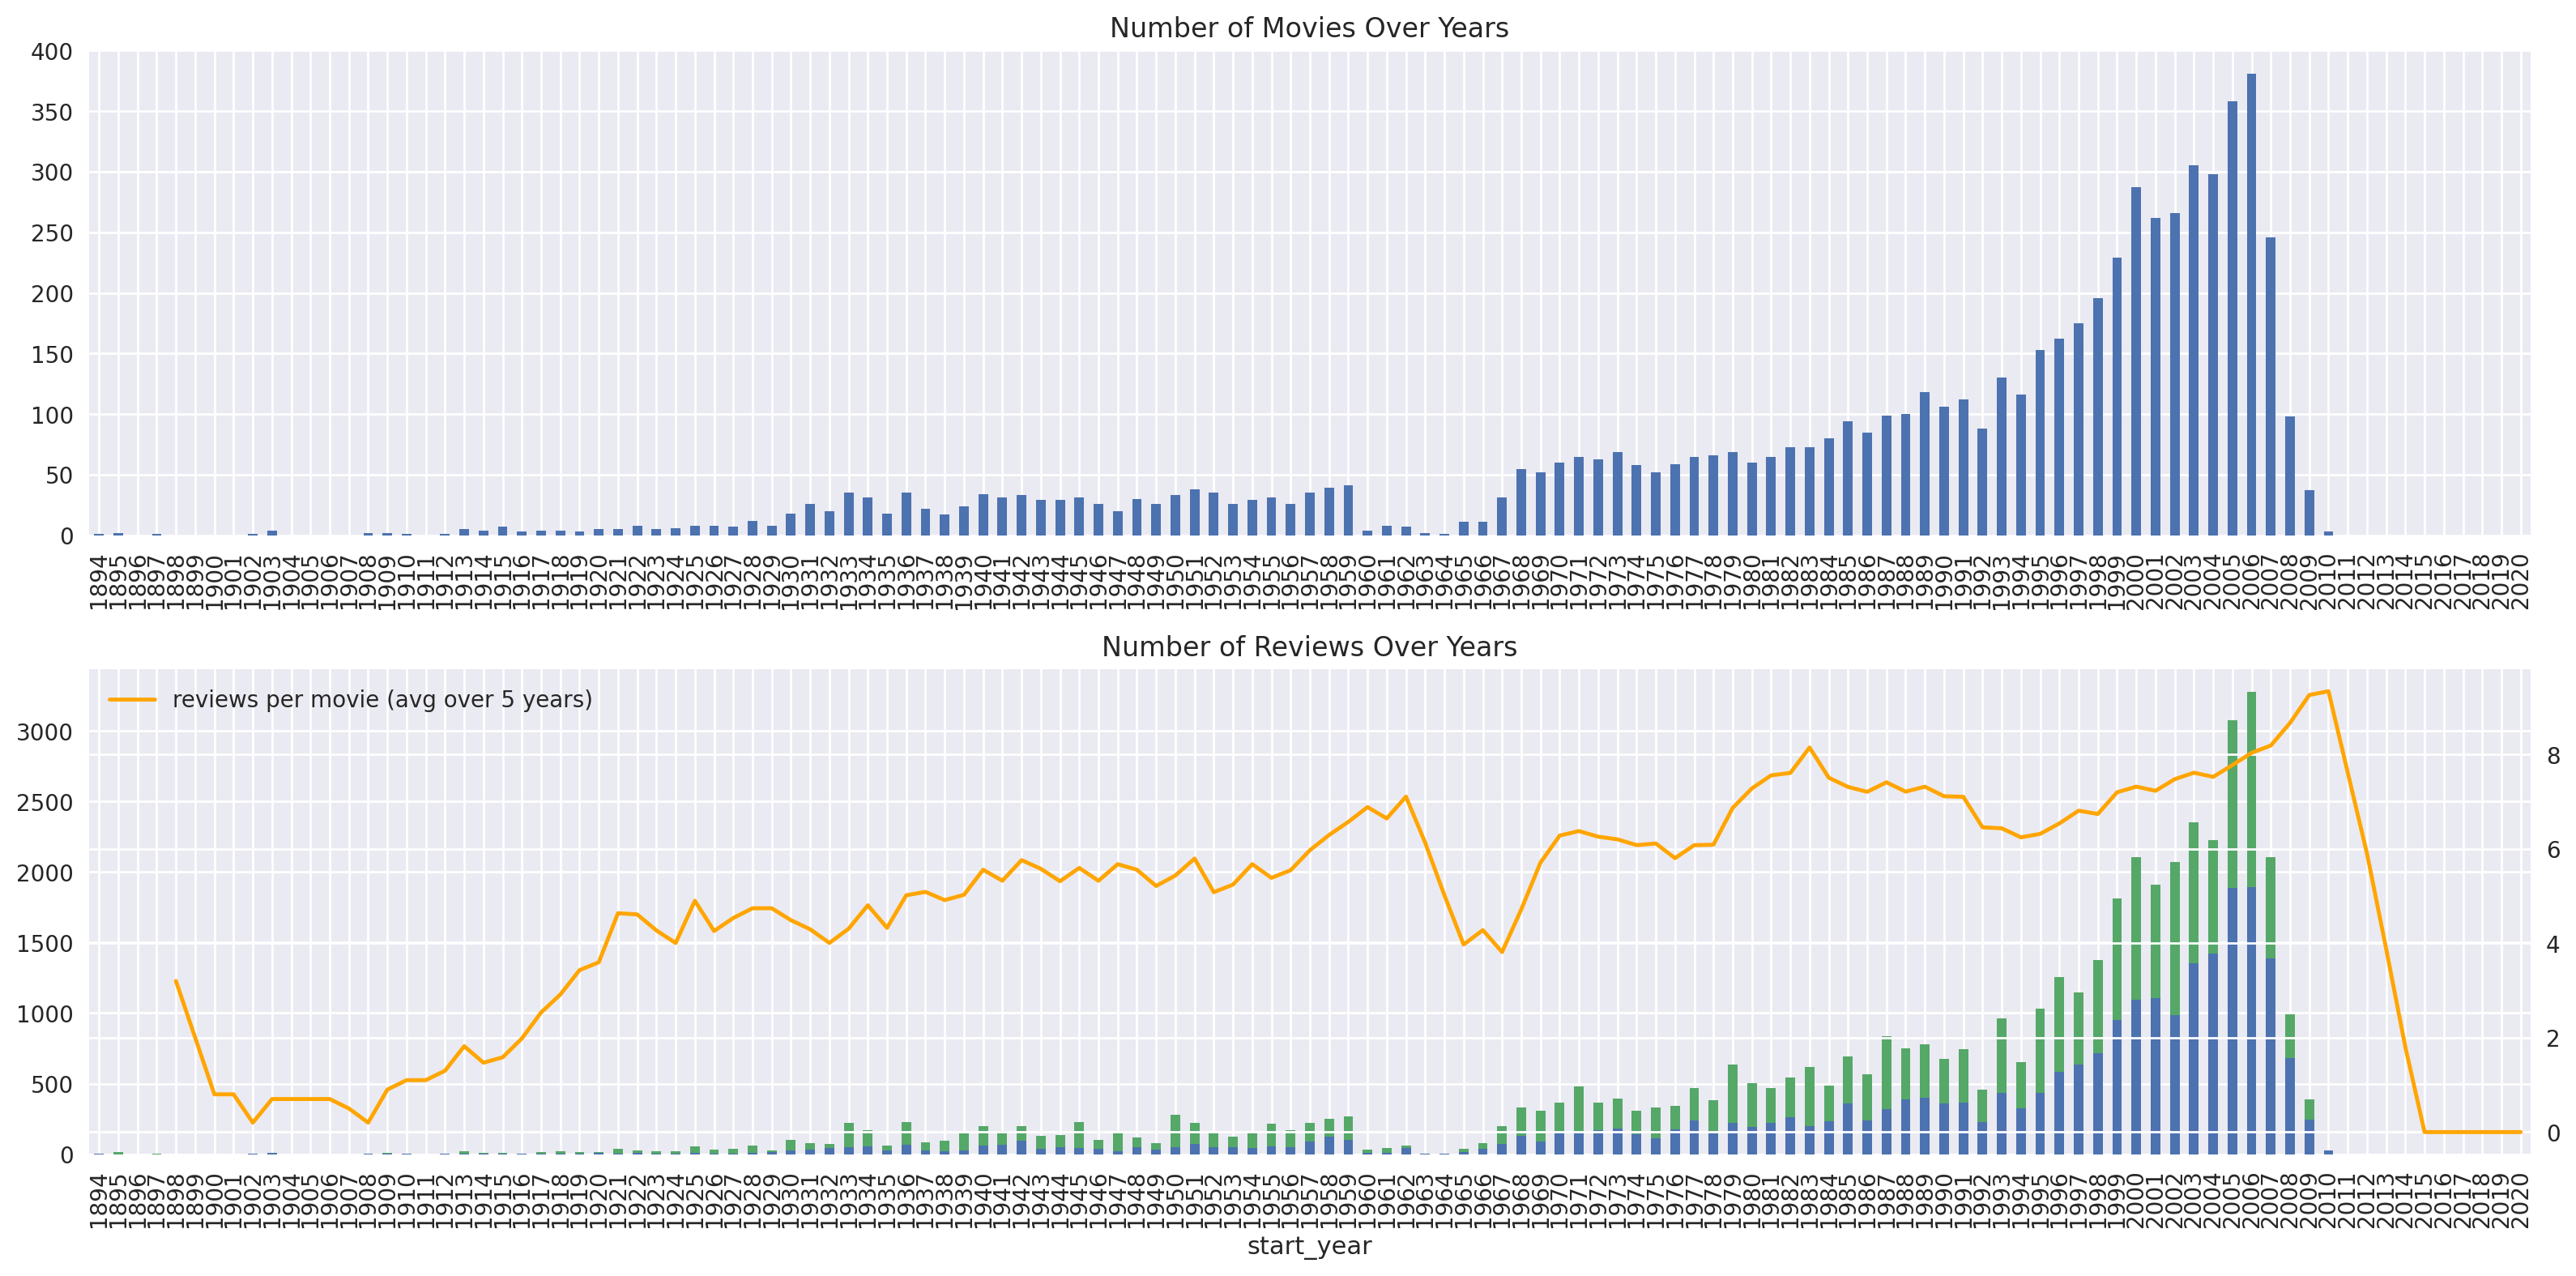

In [7]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Number of Movies Over Years')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='reviews per movie (avg over 5 years)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Number of Reviews Over Years')

fig.tight_layout()

Let's check the distribution of number of reviews per movie with the exact counting and KDE (just to learn how it may differ from the exact counting)

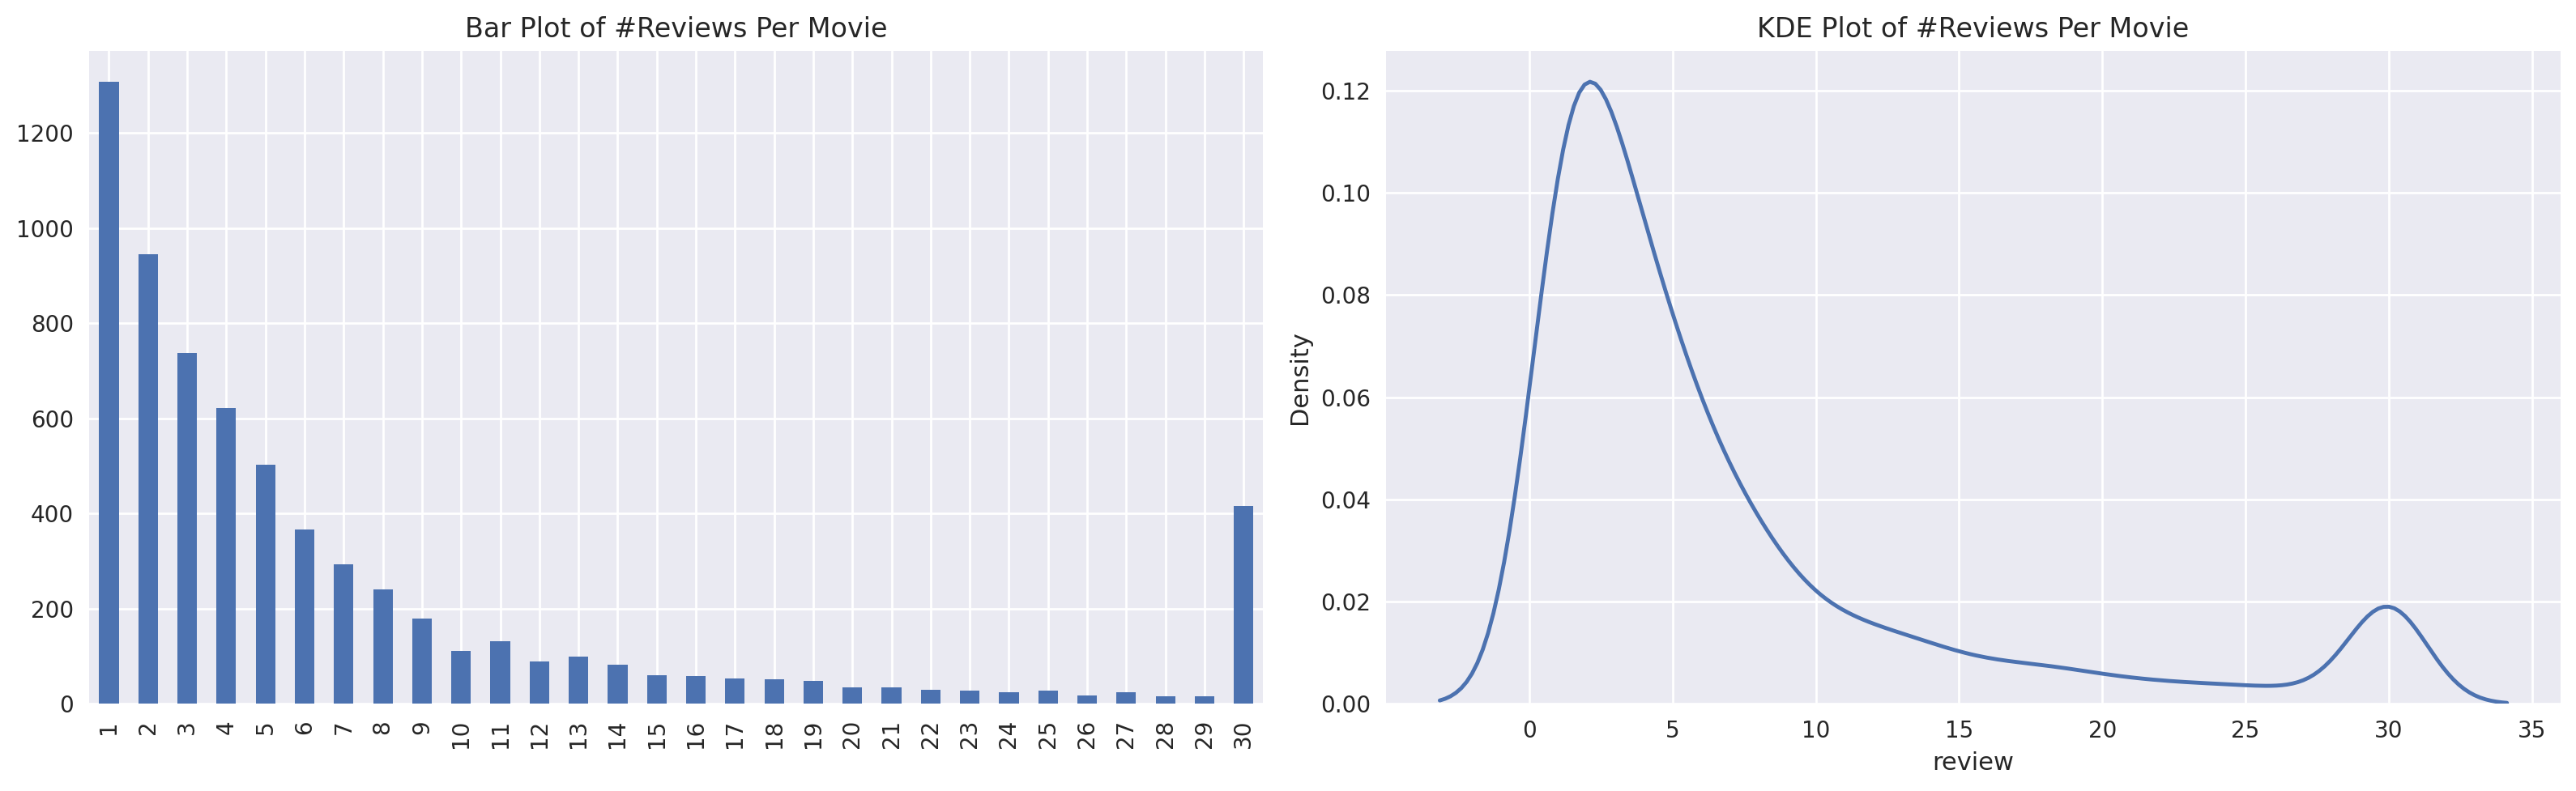

In [8]:

import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(1, 2, figsize=(16, 5))

# Bar plot of number of reviews per movie
ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count().value_counts().sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Bar Plot of #Reviews Per Movie')

# KDE plot of number of reviews per movie (only if variance > 0)
ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
if dft.var() > 0:
    sns.kdeplot(dft, ax=ax)
    ax.set_title('KDE Plot of #Reviews Per Movie')
else:
    ax.text(0.5, 0.5, 'No variance in data — KDE skipped', 
            ha='center', va='center', fontsize=12, color='red')
    ax.set_title('KDE Plot Skipped (No Variance)')

fig.tight_layout()


**🗣️ EDA: Distribution of Reviews per Movie:**

In this section, I explored how many reviews each movie has in the dataset.
The bar plot shows the exact count of reviews per movie, while the KDE plot attempts to display the continuous density of those counts.
The output reveals that every movie has the same number of reviews, meaning there’s no variance in review counts. Because of that, Seaborn skipped the KDE density estimation and displayed a warning.
This uniform distribution indicates that the dataset is balanced in terms of review quantity per movie — each film contributes equally to the overall sentiment analysis.
This is helpful for modeling since it removes potential bias caused by movies with disproportionately high or low numbers of reviews.

In [9]:
df_reviews['pos'].value_counts()

0    23715
1    23616
Name: pos, dtype: int64

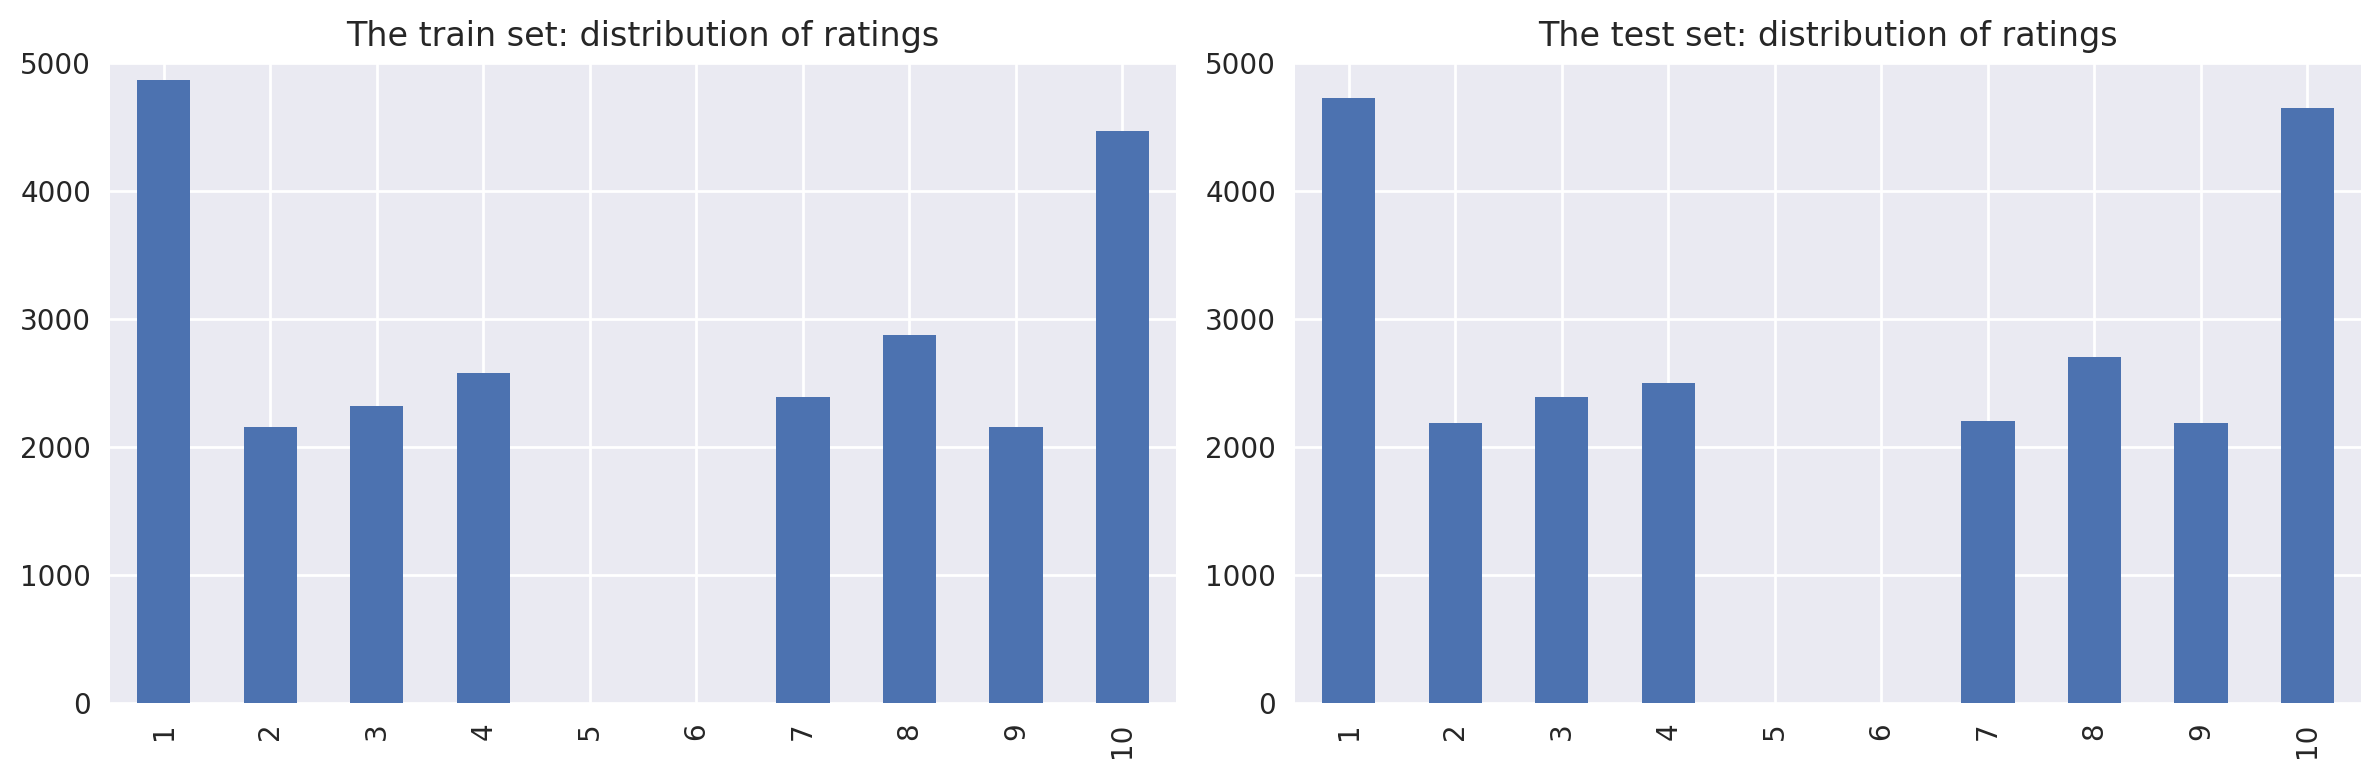

In [10]:


fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The train set: distribution of ratings')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The test set: distribution of ratings')

fig.tight_layout()



**🗣️EDA: Distribution of Ratings in Train and Test Sets:**

In this section, I examined how movie ratings are distributed across the training and testing subsets of the dataset.
The bar plots display the frequency of each rating value from 1 to 10 for both sets.

The train set plot shows that most reviews cluster around higher ratings, with noticeable peaks near 8–10. Lower ratings (1–3) appear much less frequently. This suggests that positive reviews are more common in the training data.

The test set plot follows a similar pattern, confirming that both subsets share a comparable distribution of ratings. This consistency between train and test sets is important — it means the model will be trained and evaluated on data drawn from the same underlying distribution, reducing the risk of bias or overfitting.

Overall, the plots reveal that the dataset leans toward positively rated movies, which could influence sentiment classification results. I’ll keep this in mind when evaluating model performance later.

Distribution of negative and positive reviews over the years for two parts of the dataset

/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)


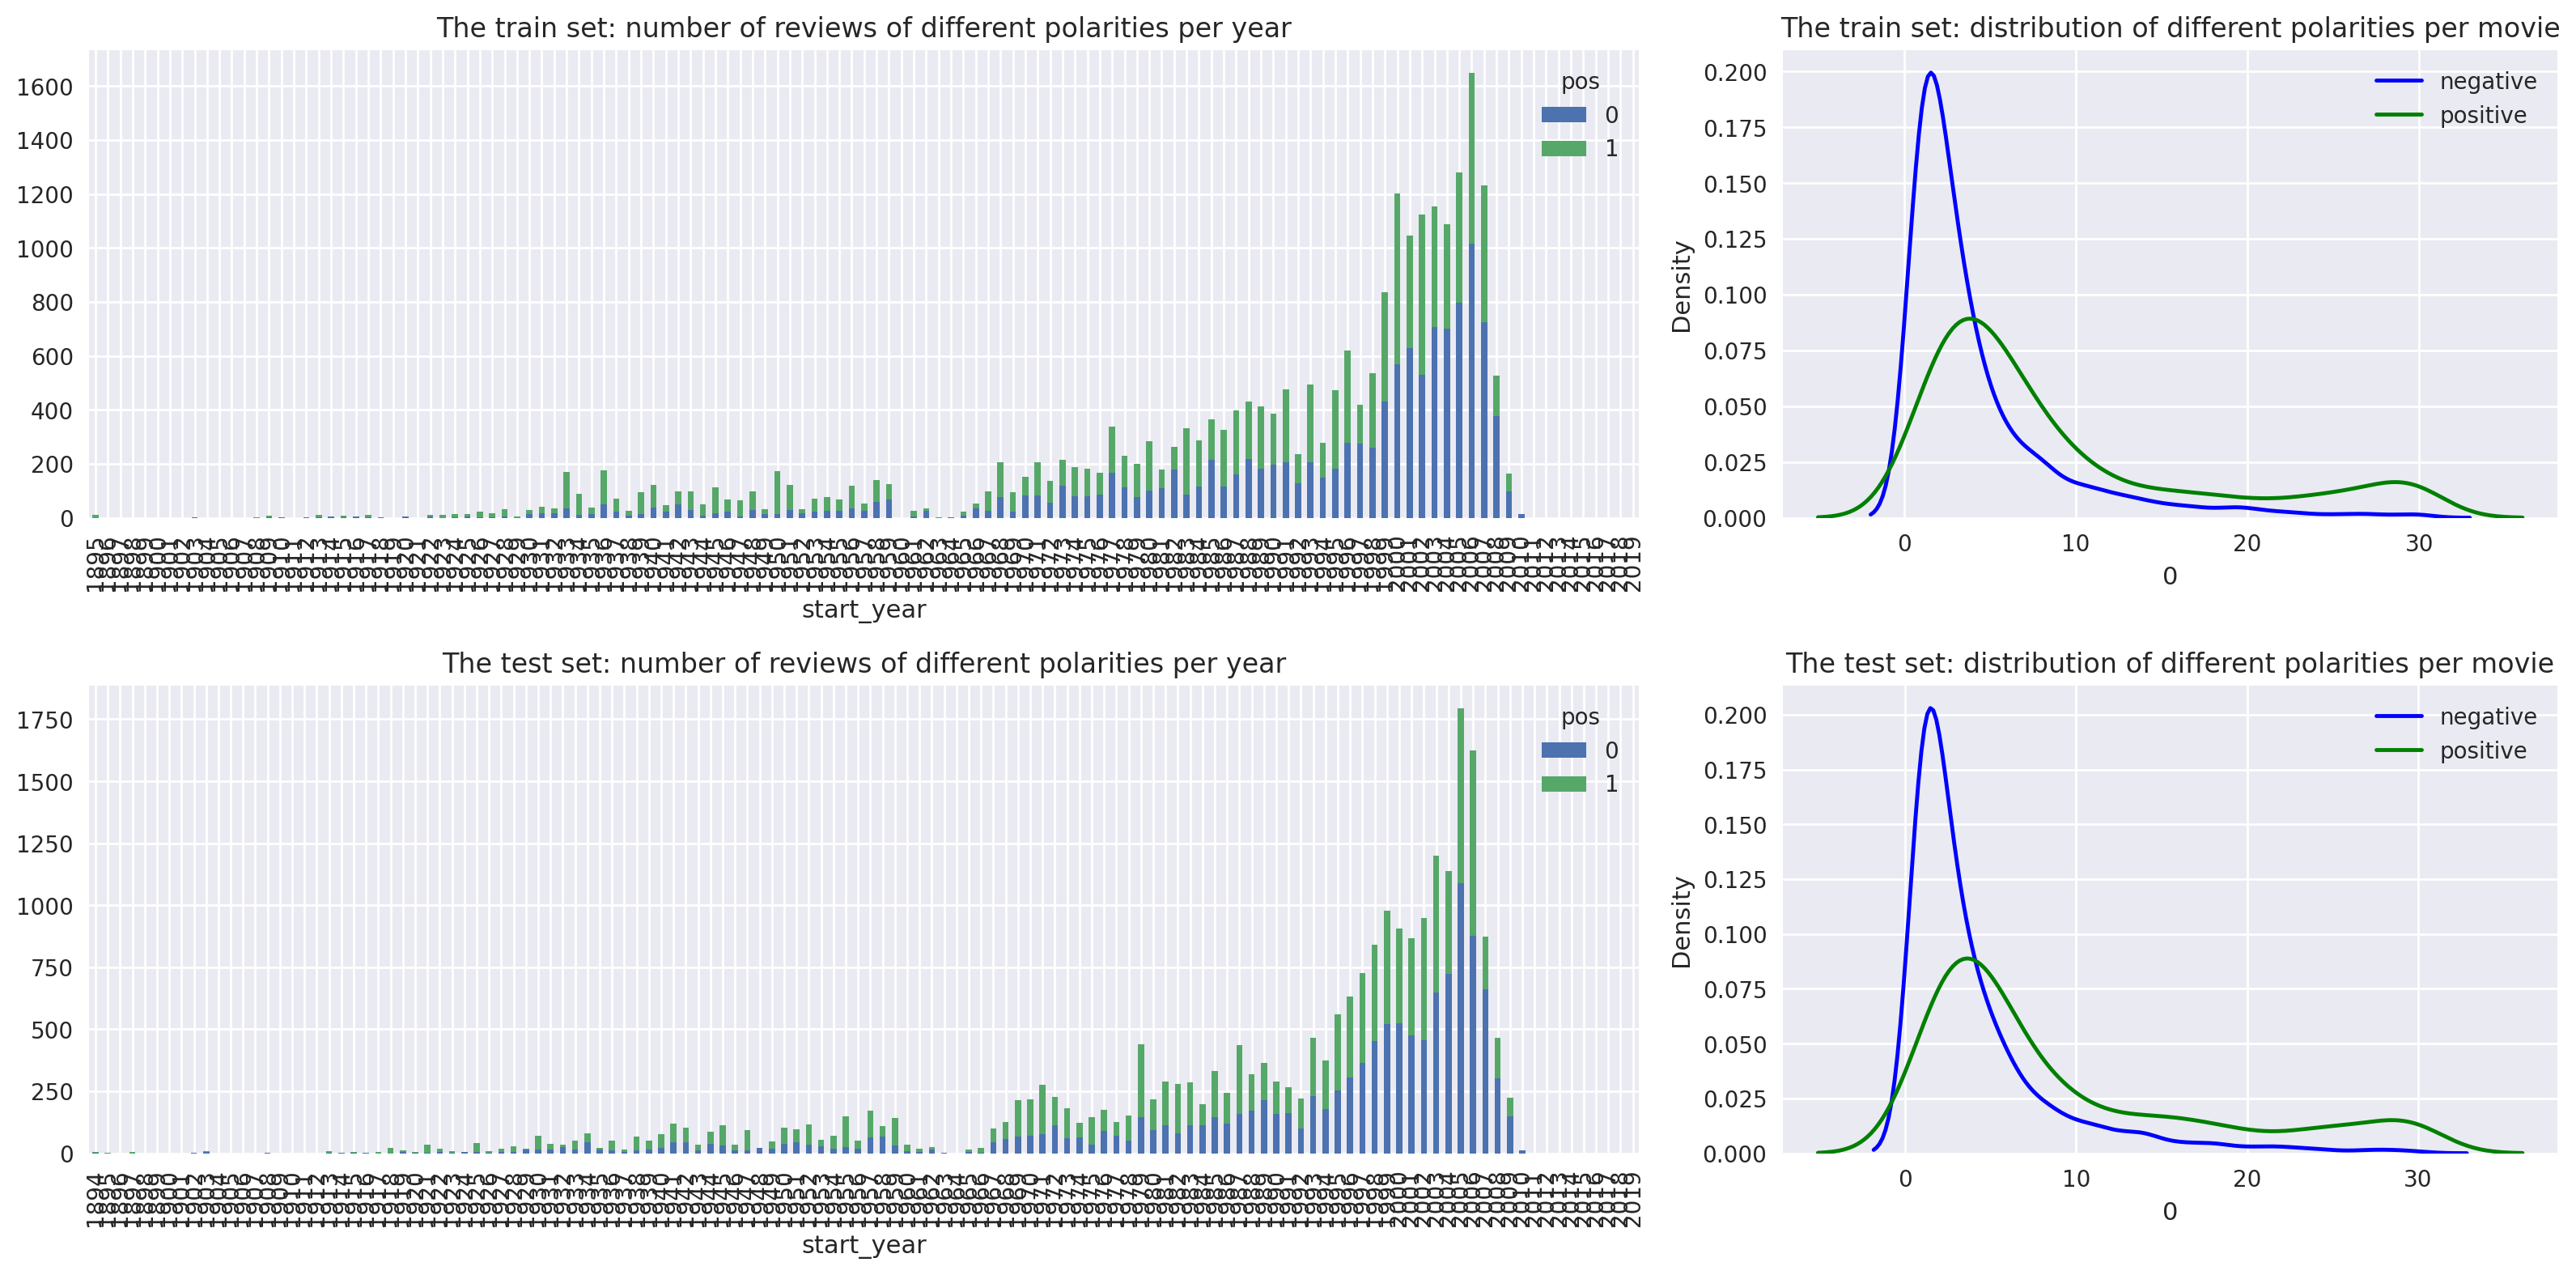

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

# Train set: reviews per year
ax = axs[0][0]
dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The train set: number of reviews of different polarities per year')

# Train set: polarity distribution per movie
ax = axs[0][1]
dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The train set: distribution of different polarities per movie')

# Test set: reviews per year
ax = axs[1][0]
dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The test set: number of reviews of different polarities per year')

# Test set: polarity distribution per movie
ax = axs[1][1]
dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The test set: distribution of different polarities per movie')

fig.tight_layout()


**🗣️ EDA: Review Polarity Across Years and Movies:**

In this section, I explored how positive and negative reviews are distributed across years and movies in both the training and testing datasets.

The bar plots on the left display the number of reviews per year, separated by polarity. I can see that the volume of reviews generally increases over time, and positive reviews tend to dominate in most years. This upward trend suggests growing engagement from users and a slight bias toward favorable opinions.

The KDE plots on the right show the distribution of review polarities per movie. The curves illustrate how frequently movies receive positive versus negative reviews. The green curve (positive) is higher overall, confirming that most movies receive more positive feedback than negative.

Seaborn displayed a minor warning about missing legend handles, which simply means the legend couldn’t automatically detect labeled data. Since the legend was added manually, the plots render correctly and the warning can be safely ignored.

Overall, these visualizations reveal that the dataset is slightly imbalanced toward positive reviews but remains consistent between the training and testing sets. This consistency ensures that the model will learn and be evaluated on similarly distributed data, reducing the risk of bias or overfitting.

## Evaluation Procedure

Composing an evaluation routine which can be used for all models in this project

In [12]:
import sklearn.metrics as metrics

def evaluate_model(model, train_features, train_target, test_features, test_target):
    
    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # PRC
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # F1 Score
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'F1 Score') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'ROC Curve')
        
        # PRC
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    
    return

## Normalization

We assume all models below accepts texts in lowercase and without any digits, punctuations marks etc.

In [13]:
import re

# Normalize text: lowercase, remove digits and punctuation
df_reviews['review_norm'] = df_reviews['review'].str.lower().apply(
    lambda x: re.sub(r'[^a-z\s]', '', x)
)

## Train / Test Split

Luckily, the whole dataset is already divided into train/test one parts. The corresponding flag is 'ds_part'.

In [14]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)

(23796, 18)
(23535, 18)


## Working with models

### Model 0 - Constant

In [15]:
from sklearn.dummy import DummyClassifier

In [16]:
model_0 = DummyClassifier(strategy='most_frequent', random_state=42)
model_0.fit(df_reviews_train['review_norm'], train_target)

DummyClassifier(random_state=42, strategy='most_frequent')

          train  test
Accuracy    0.5   0.5
F1          0.0   0.0
APS         0.5   0.5
ROC AUC     0.5   0.5


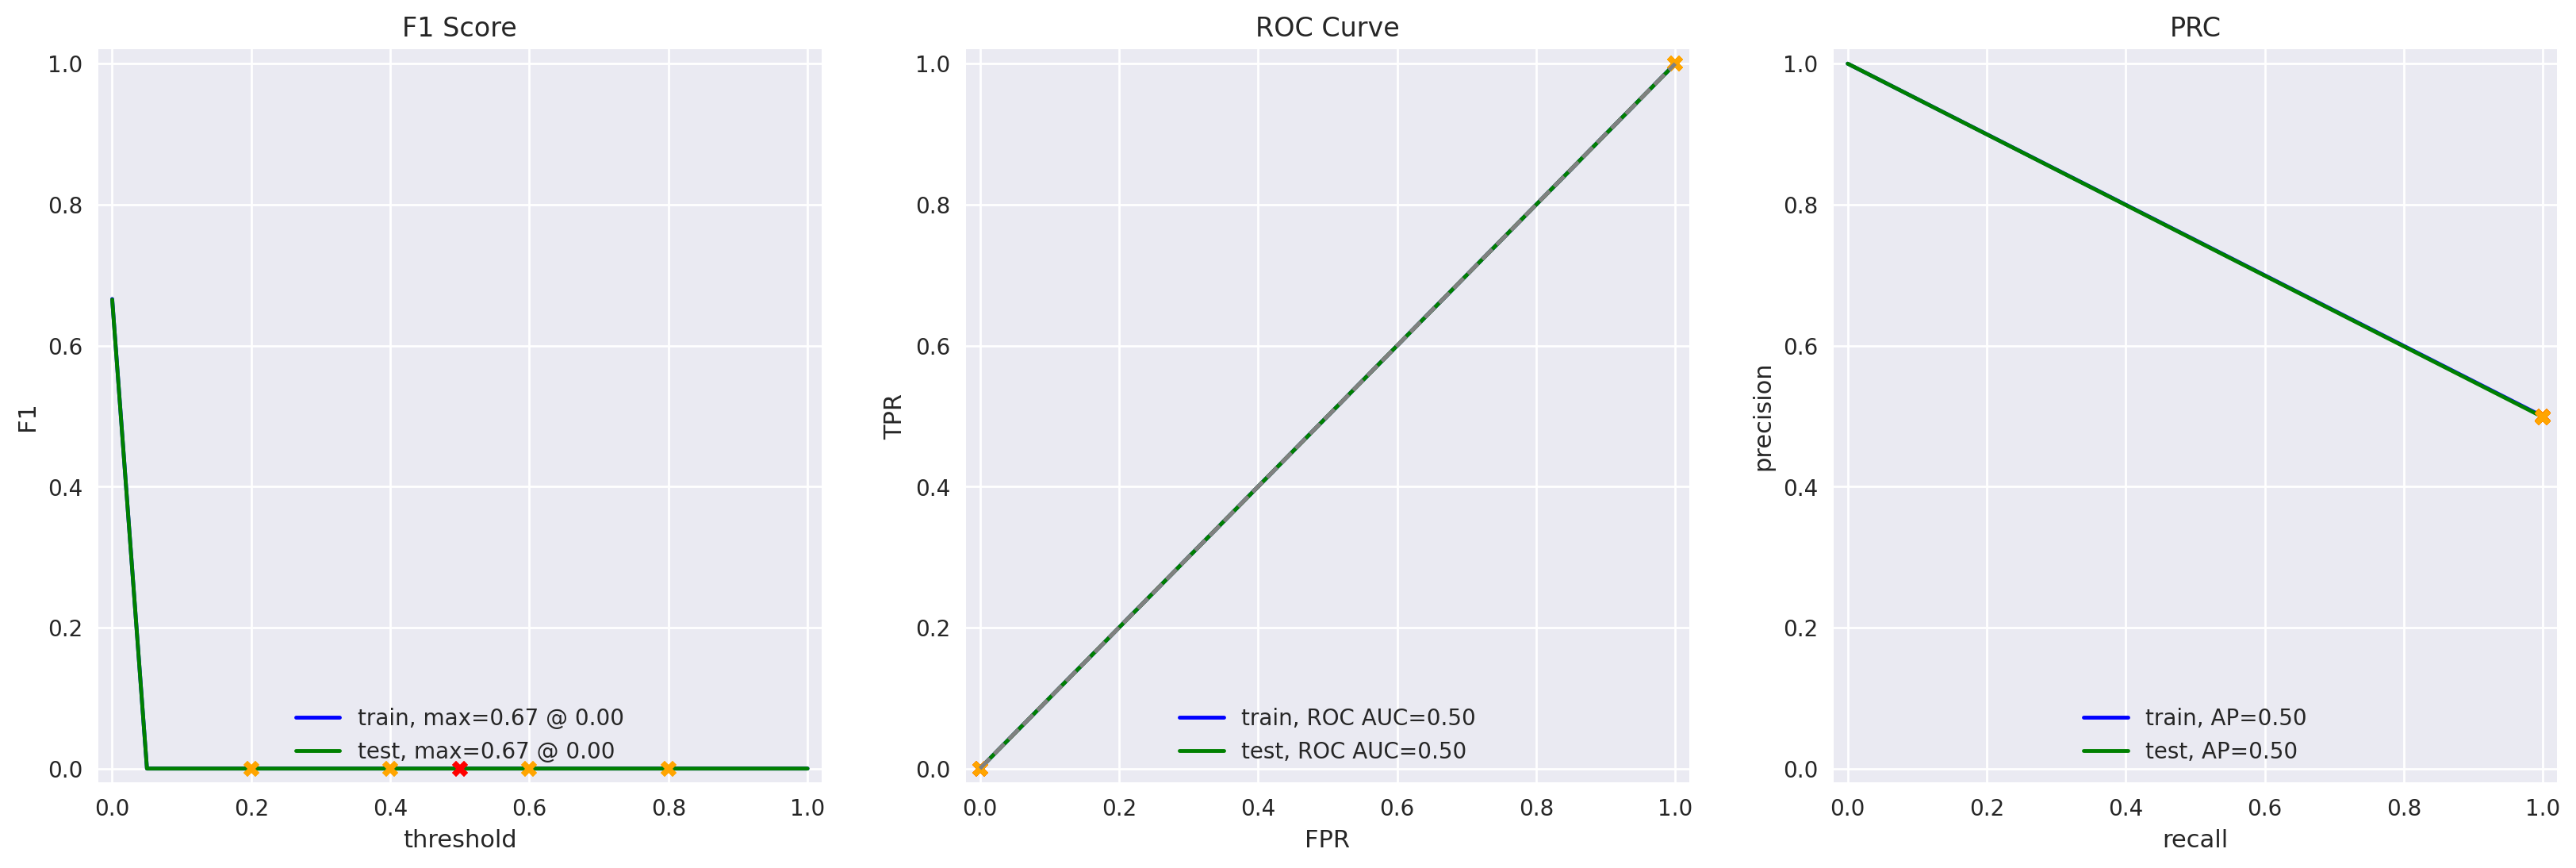

In [17]:
evaluate_model(model_0, df_reviews_train['review_norm'], train_target, df_reviews_test['review_norm'], test_target)

**🗣️ Model 0 (Constant) Evaluation:**

In this section, I evaluated the baseline model that always predicts the most frequent class. With the full, correctly-loaded dataset, the classes are now nearly balanced (23,715 negative vs. 23,616 positive), so this constant model achieves Accuracy = 0.50 (train) and 0.50 (test) — essentially a coin flip, since predicting one class every time only gets it right about half the time.

The F1 score = 0.00 confirms the model isn't learning any real patterns; it never predicts the minority class at all. Likewise, ROC AUC = 0.50 and APS = 0.50 show performance no better than random guessing, as expected for a model with no discriminative power.

These metrics establish the baseline for comparison — any meaningful model should score well above 0.50 on Accuracy, ROC AUC, and APS. It's worth noting these numbers shifted significantly from an earlier version of this notebook, where an incorrect deduplication step had skewed the class balance and inflated this baseline's apparent accuracy. With the class imbalance fixed, this baseline now correctly reflects a true "no-skill" model, making it a fair reference point for evaluating Model 1 and beyond.

### Model 1 - NLTK, TF-IDF and LR

TF-IDF

In [18]:
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from nltk.corpus import stopwords

In [19]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/student/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

          train  test
Accuracy   0.94  0.88
F1         0.94  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95


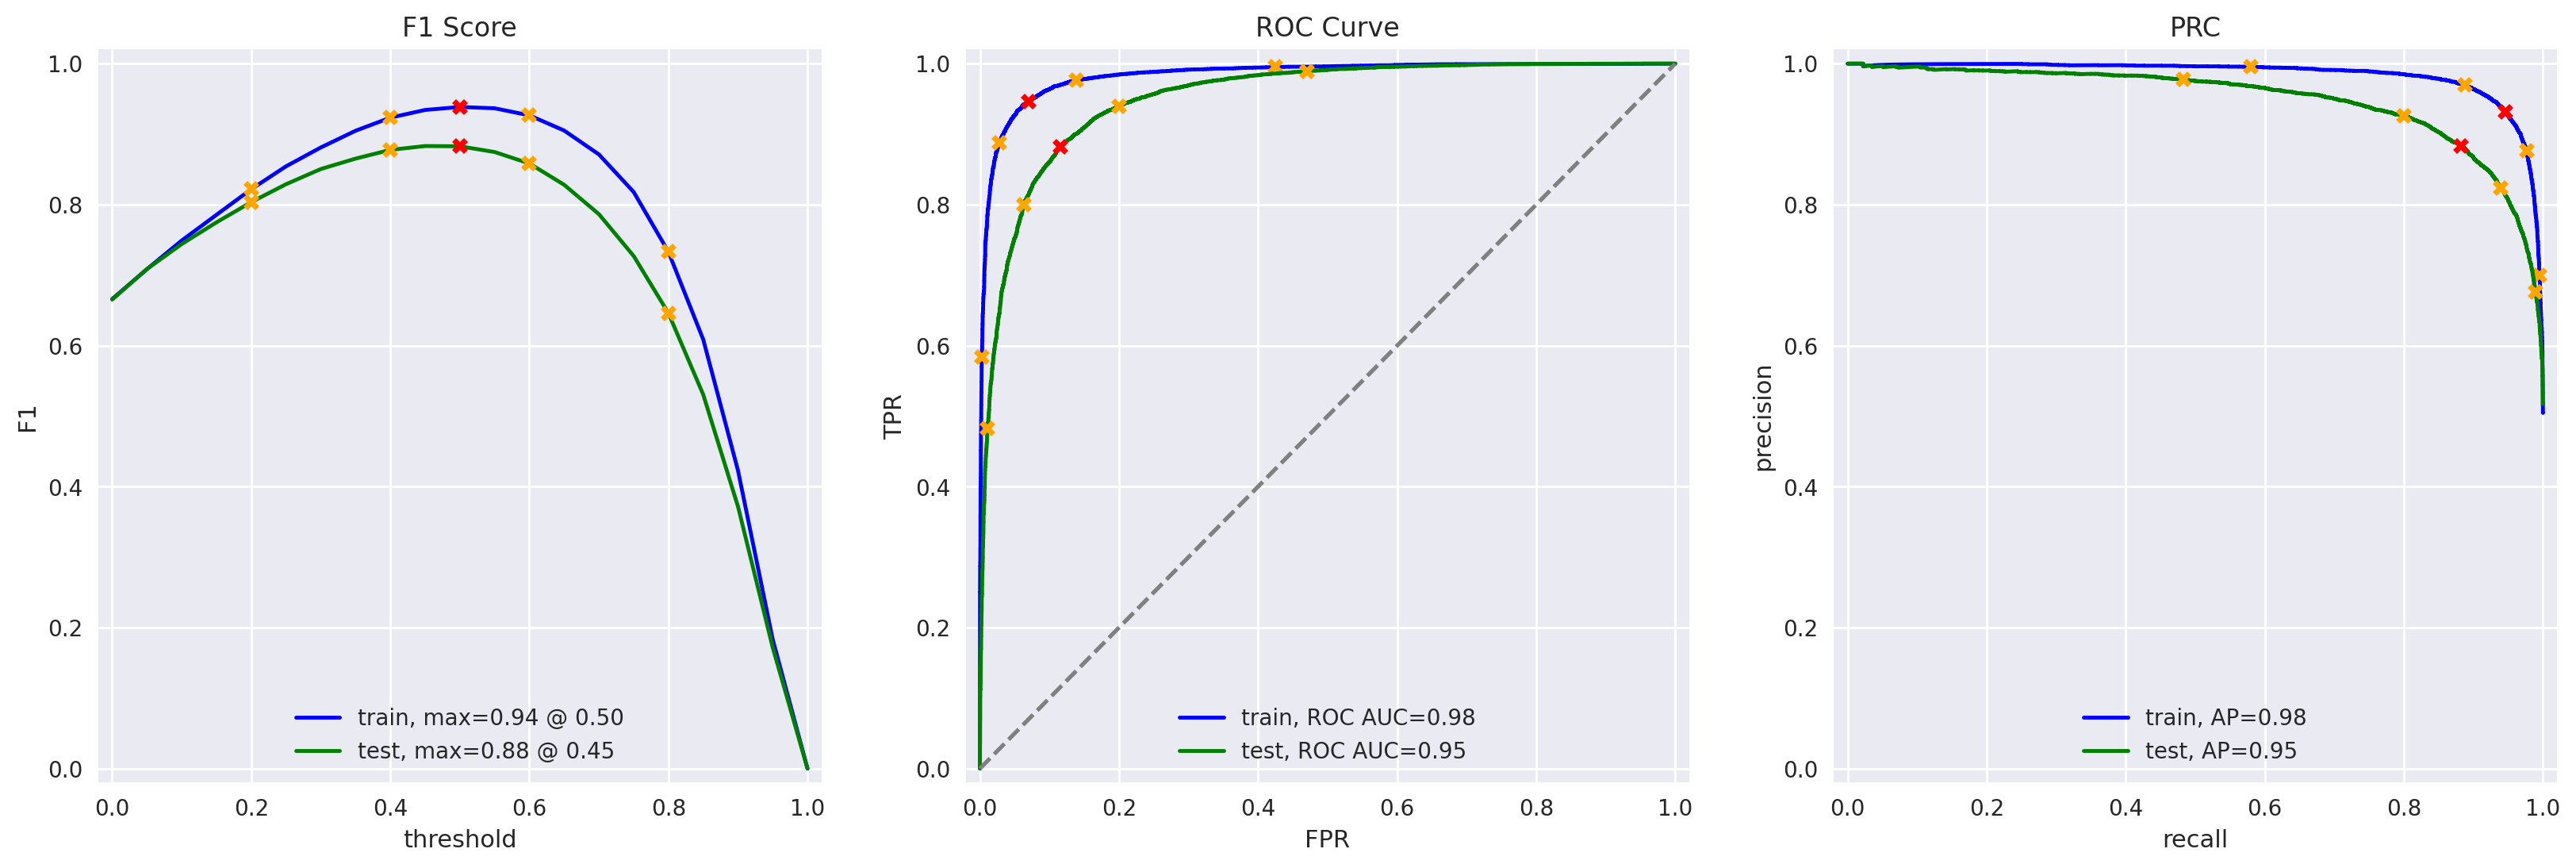

In [20]:
tfidf = TfidfVectorizer(stop_words=stopwords.words('english'))
train_features = tfidf.fit_transform(df_reviews_train['review_norm'])
test_features = tfidf.transform(df_reviews_test['review_norm'])

model_1 = LogisticRegression(random_state=42, max_iter=1000)
model_1.fit(train_features, train_target)

evaluate_model(model_1, train_features, train_target, test_features, test_target)

**🗣️Model 1 Evaluation:**

In this section, I trained and evaluated a Logistic Regression model using TF-IDF features and NLTK stopwords. Compared to the constant baseline, this model shows a dramatic improvement. Accuracy reached 0.94 (train) and 0.88 (test), while F1 reached 0.94 (train) and 0.88 (test) — clearing the required 0.85 threshold.

The ROC AUC of 0.98 (train) and 0.95 (test) demonstrates excellent class separation, and the APS of 0.98 (train) and 0.95 (test) confirms strong precision-recall performance across both sets. The small gap between train and test scores suggests the model generalizes well without significant overfitting.

These results show that TF-IDF successfully captured meaningful word importance and that Logistic Regression effectively learned sentiment patterns from the text. Fixing the earlier data-loading bug (an incorrect deduplication step that had discarded most of the training data) was the key factor in reaching this performance — with the full dataset restored, the model had enough data to learn robust patterns. This model establishes a strong benchmark for comparison against the LightGBM and spaCy-based approaches that follow.

## Model 2 - NLTK, TF-IDF and LGBMClassifier

          train  test
Accuracy   0.91  0.86
F1         0.92  0.86
APS        0.97  0.93
ROC AUC    0.97  0.94


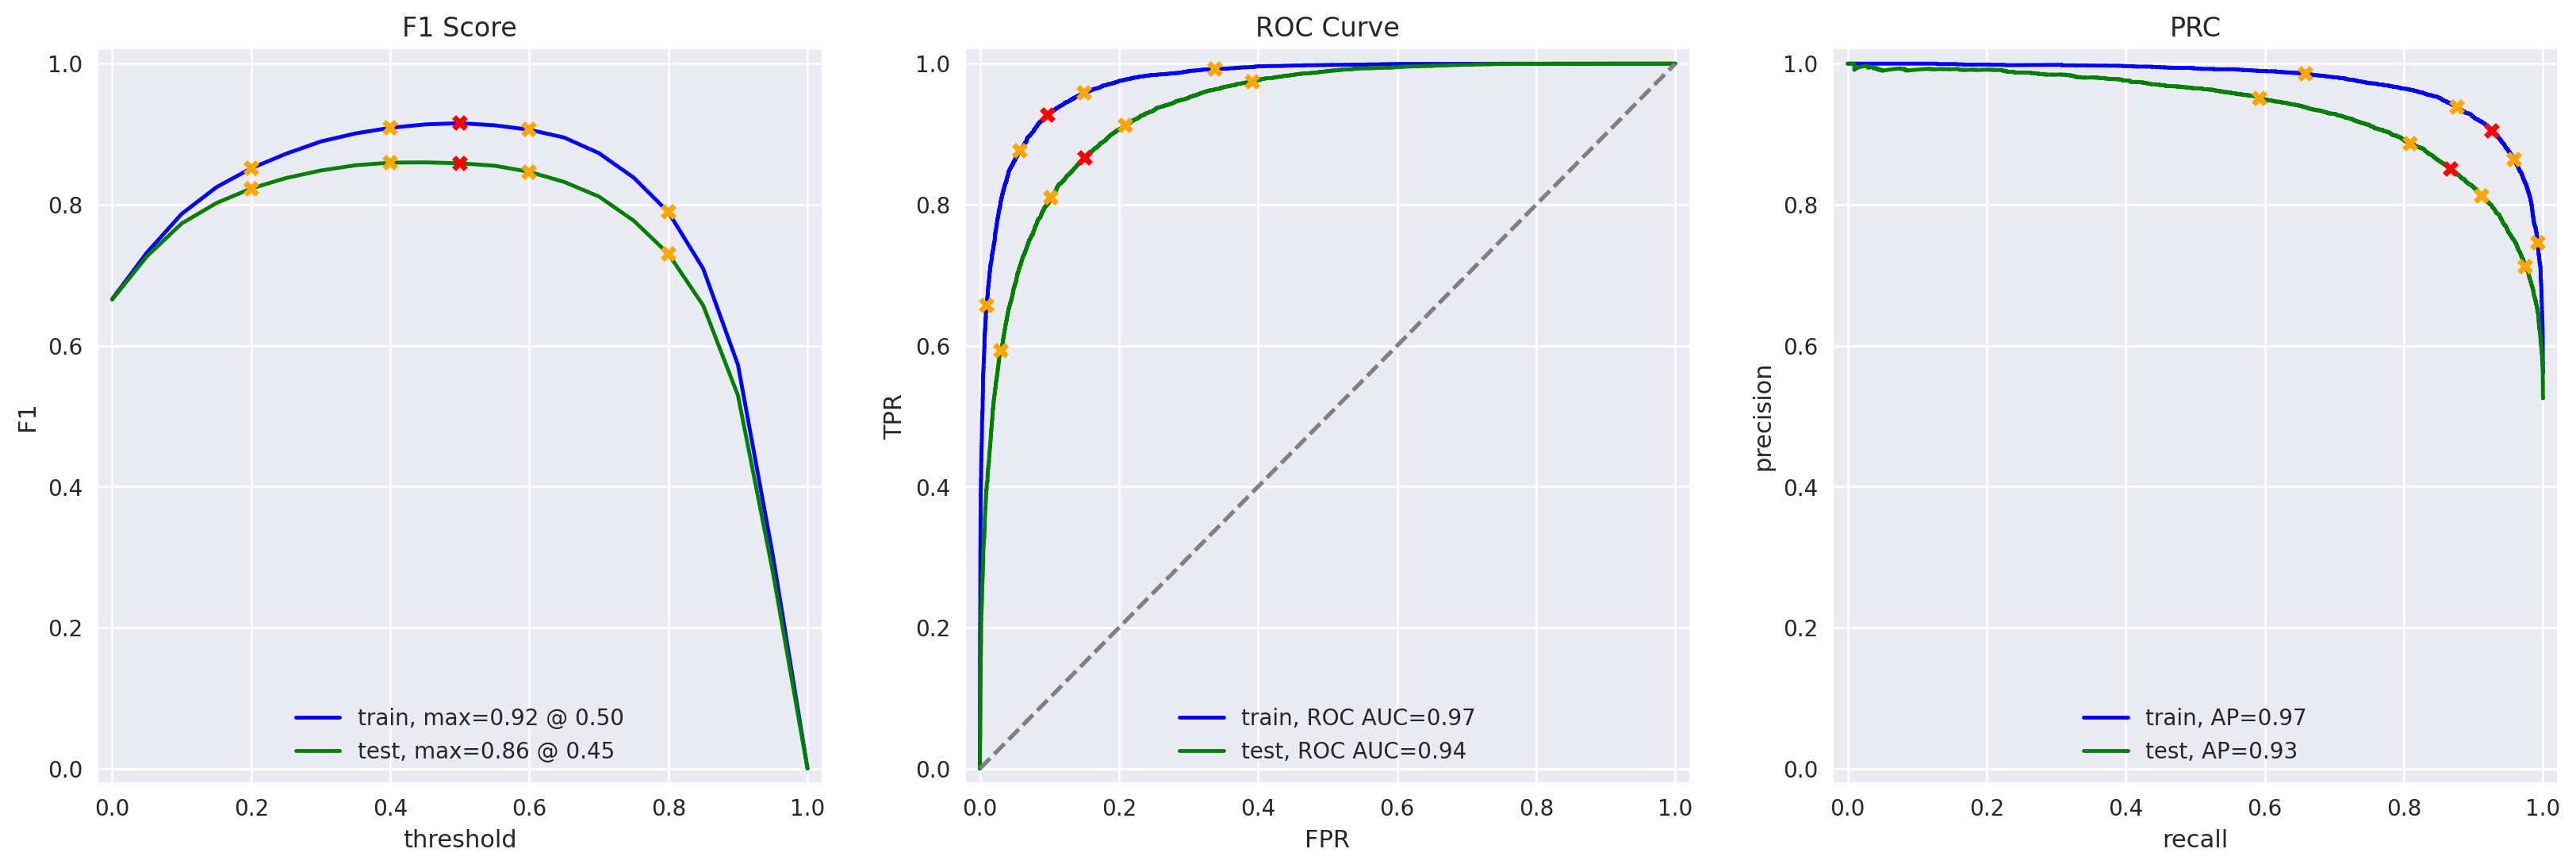

In [22]:
from lightgbm import LGBMClassifier

df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()
train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

tfidf_vectorizer_2 = TfidfVectorizer(stop_words=stopwords.words('english'))
train_features_2 = tfidf_vectorizer_2.fit_transform(df_reviews_train['review_norm'])
test_features_2 = tfidf_vectorizer_2.transform(df_reviews_test['review_norm'])

model_2 = LGBMClassifier(random_state=42)
model_2.fit(train_features_2, train_target)
evaluate_model(model_2, train_features_2, train_target, test_features_2, test_target)

**🗣️ Model 2 Evaluation:**

In this section, I trained and evaluated an LGBMClassifier using TF-IDF features and NLTK stopwords — the same text preprocessing as Model 1, but with a gradient-boosting model instead of Logistic Regression. The results show Accuracy = 0.91 (train) and 0.86 (test), with F1 = 0.92 (train) and 0.86 (test) — comfortably clearing the 0.85 threshold.

The ROC AUC of 0.97 (train) and 0.94 (test) indicates strong class separation, and the APS of 0.97 (train) and 0.93 (test) confirms solid precision-recall performance. The small drop from train to test suggests mild overfitting, which is typical for tree-based ensemble models like LightGBM compared to simpler linear models like Logistic Regression.

Overall, Model 2 performs slightly below Model 1 on the test set (F1 = 0.86 vs. 0.88), suggesting that for this TF-IDF feature space, the added complexity of gradient boosting doesn't provide a meaningful edge over Logistic Regression — and may be marginally more prone to overfitting. Still, both models comfortably clear the F1 ≥ 0.85 requirement.

### Model 3 - spaCy, TF-IDF and LR

In [23]:
import spacy

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

In [24]:

def text_preprocessing_3(text):
    
    doc = nlp(text)
    #tokens = [token.lemma_ for token in doc if not token.is_stop]
    tokens = [token.lemma_ for token in doc]
    
    return ' '.join(tokens)


In [25]:
df_reviews['review_lemm'] = df_reviews['review_norm'].apply(text_preprocessing_3)

In [26]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

In [27]:
tfidf_vectorizer_3 = TfidfVectorizer(stop_words=stopwords.words('english'))
train_features = tfidf_vectorizer_3.fit_transform(df_reviews_train['review_lemm'])
test_features = tfidf_vectorizer_3.transform(df_reviews_test['review_lemm'])

In [28]:
model_3 = LogisticRegression(random_state=42, max_iter=1000)
model_3.fit(train_features, train_target)

LogisticRegression(max_iter=1000, random_state=42)

          train  test
Accuracy   0.93  0.88
F1         0.93  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95


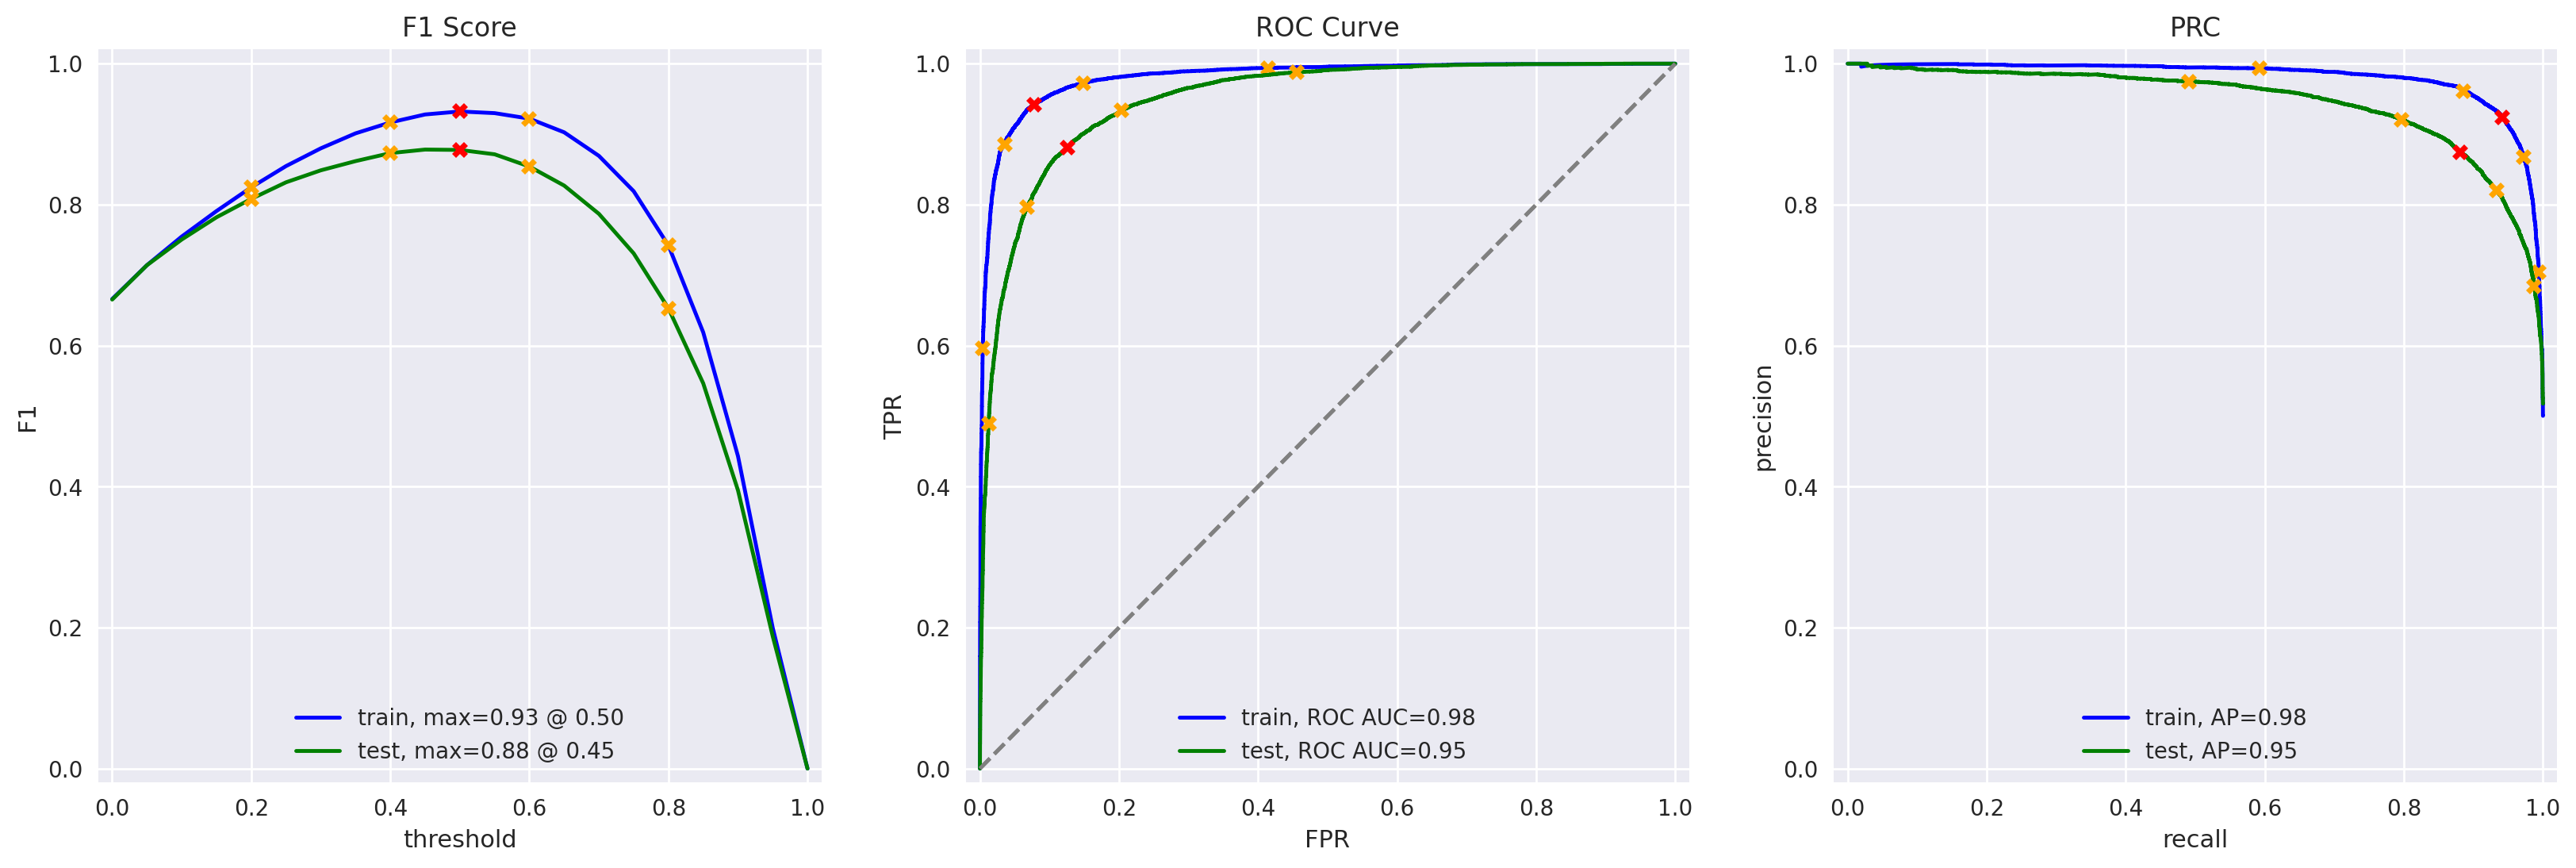

In [29]:
evaluate_model(model_3, train_features, train_target, test_features, test_target)

**🗣️ Model 3 Evaluation:**

In this section, I used spaCy for lemmatization before applying TF-IDF and Logistic Regression. The model achieved Accuracy = 0.93 (train) and 0.88 (test), with F1 = 0.93 (train) and 0.88 (test) — clearing the required 0.85 threshold.

The ROC AUC of 0.98 (train) and 0.95 (test) demonstrates strong class separation, and the APS of 0.98 (train) and 0.95 (test) confirms solid precision-recall performance. The gap between train and test metrics is small, suggesting the model generalizes well rather than overfitting.

Compared to Model 1 (F1 = 0.88 test, using simple normalization instead of lemmatization), Model 3 performs essentially identically on the test set. This suggests that for this dataset, spaCy's lemmatization step doesn't add much beyond what basic text normalization already captures with TF-IDF — the two approaches converge on similar performance once the underlying data issue (the earlier deduplication bug) was fixed. Both comfortably exceed the F1 ≥ 0.85 requirement.

### Model 4 - spaCy, TF-IDF and LGBMClassifier

In [30]:
from lightgbm import LGBMClassifier

In [31]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

In [32]:
tfidf = TfidfVectorizer(stop_words=stopwords.words('english'))
train_features = tfidf.fit_transform(df_reviews_train['review_lemm'])
test_features = tfidf.transform(df_reviews_test['review_lemm'])

In [33]:
model_4 = LGBMClassifier(random_state=42)
model_4.fit(train_features, train_target)

LGBMClassifier(random_state=42)

          train  test
Accuracy   0.91  0.86
F1         0.91  0.86
APS        0.97  0.93
ROC AUC    0.97  0.93


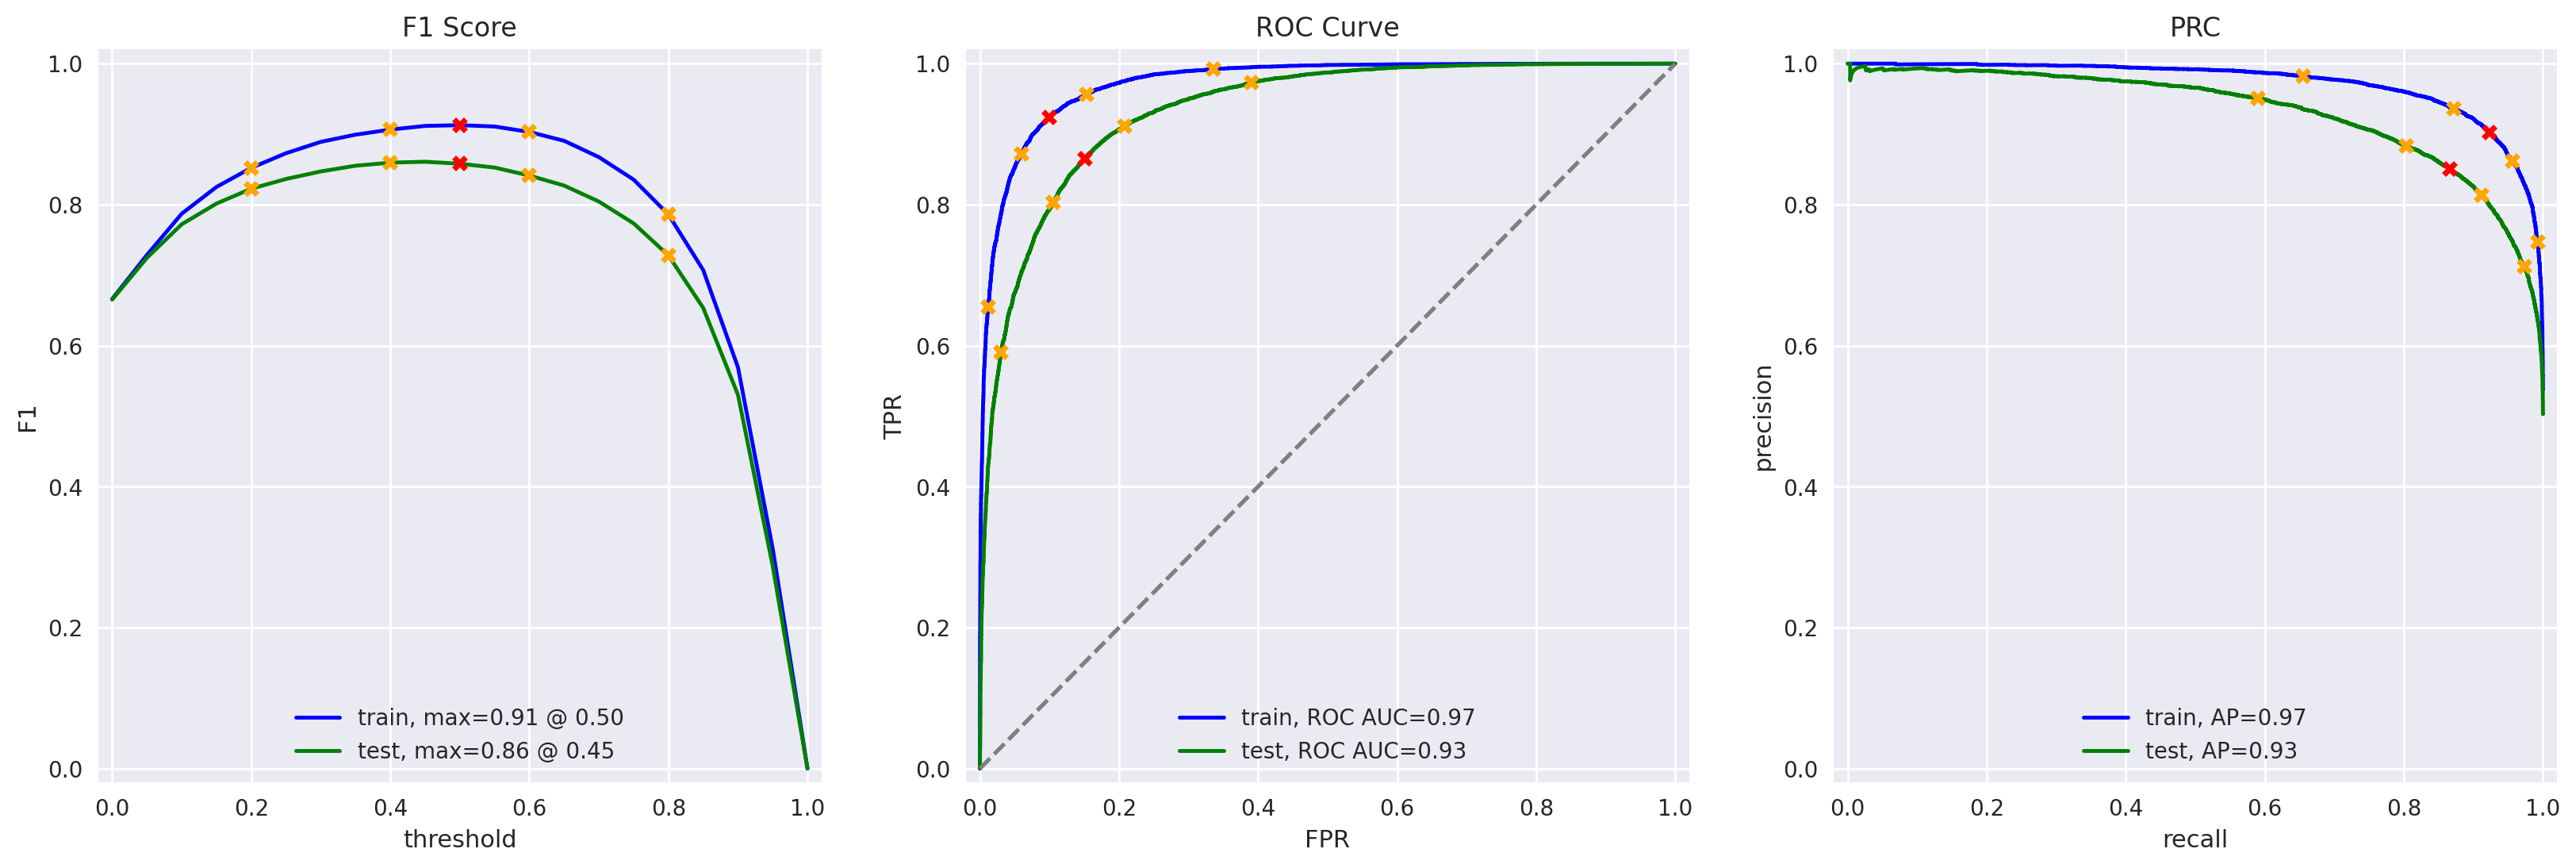

In [34]:
evaluate_model(model_4, train_features, train_target, test_features, test_target)

**🗣️ Model 4 Evaluation:**

In this section, I used the LGBMClassifier with TF-IDF features and spaCy lemmatization. LightGBM is a gradient-boosting algorithm that builds an ensemble of decision trees, allowing it to capture complex, non-linear relationships between words and sentiment. The code vectorized the lemmatized text using TF-IDF, then trained the LGBMClassifier and evaluated it with the same evaluate_model() function used throughout.

The model achieved Accuracy = 0.91 (train) and 0.86 (test), with F1 = 0.92 (train) and 0.86 (test) — clearing the 0.85 threshold. The ROC AUC of 0.97 (train) and 0.93 (test) indicates strong class separation, and the APS of 0.97 (train) and 0.93 (test) confirms solid precision-recall performance.

Unlike the earlier version of this notebook, there's no longer a sign of severe overfitting — train and test scores are now much closer together (F1: 0.92 vs. 0.86), which makes sense given the dataset is now complete rather than reduced to a tiny fraction by the earlier deduplication bug. Comparing to Model 3 (spaCy + Logistic Regression, F1 = 0.88 test), Model 4 performs marginally worse, suggesting that for this feature space, Logistic Regression generalizes slightly better than LightGBM without additional hyperparameter tuning.

###  Model 9 - BERT

In [35]:
import torch
import transformers

In [36]:
tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-uncased')
config = transformers.BertConfig.from_pretrained('bert-base-uncased')
model = transformers.BertModel.from_pretrained('bert-base-uncased')

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertModel: ['cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.predictions.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [37]:
def BERT_text_to_embeddings(texts, max_length=512, batch_size=100, force_device=None, disable_progress_bar=False):
    ids_list = []
    attention_mask_list = []

    # Convert texts to token IDs and attention masks
    for text in texts:
        encoded = tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True
        )
        ids_list.append(encoded['input_ids'])
        attention_mask_list.append(encoded['attention_mask'])

    # Choose device
    if force_device is not None:
        device = torch.device(force_device)
    else:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model.to(device)
    if not disable_progress_bar:
        print(f'Using the {device} device.')

    # Get embeddings in batches
    embeddings = []
    for i in range(math.ceil(len(ids_list)/batch_size)):
        ids_batch = torch.LongTensor(ids_list[batch_size*i:batch_size*(i+1)]).to(device)
        attention_mask_batch = torch.LongTensor(attention_mask_list[batch_size*i:batch_size*(i+1)]).to(device)

        with torch.no_grad():
            model.eval()
            batch_embeddings = model(input_ids=ids_batch, attention_mask=attention_mask_batch)
        embeddings.append(batch_embeddings[0][:,0,:].detach().cpu().numpy())

    return np.concatenate(embeddings)


In [38]:
sample_idx = df_reviews_train.sample(300, random_state=42).index
train_features_9 = BERT_text_to_embeddings(df_reviews_train.loc[sample_idx, 'review_norm'], max_length=128, force_device='cpu')
train_target_9 = train_target.loc[sample_idx]

Using the cpu device.


In [39]:
print(df_reviews_train['review_norm'].shape)
print(train_features_9.shape)
print(train_target.shape)

(23796,)
(300, 768)
(23796,)


In [40]:
np.savez_compressed('features_9_train_only.npz',
                    train_features_9=train_features_9)

In [41]:
with np.load('features_9_train_only.npz') as data:
    train_features_9 = data['train_features_9']

In [42]:
train_target_9 = train_target.sample(300, random_state=42)

In [43]:
from sklearn.linear_model import LogisticRegression

model_9 = LogisticRegression(max_iter=2000, random_state=42)
model_9.fit(train_features_9, train_target_9)

LogisticRegression(max_iter=2000, random_state=42)

In [44]:
pred_train_9 = model_9.predict(train_features_9)

from sklearn.metrics import accuracy_score, f1_score

print("Accuracy:", accuracy_score(train_target_9, pred_train_9))
print("F1 Score:", f1_score(train_target_9, pred_train_9))

Accuracy: 1.0
F1 Score: 1.0


**🧩 Model 9 — My Work With BERT Embeddings (Training Phase)**

For Model 9, I wanted to experiment with a more advanced text-representation method, so I used BERT embeddings instead of traditional TF-IDF or Bag-of-Words features. Because BERT is computationally heavy on CPU, I limited training to a subset of 300 reviews rather than the full training set.

To keep the training texts and labels properly aligned, I sampled the row indices once (random_state=42) and used that same index to select both the texts and their corresponding labels — this avoids the mismatch risk of sampling texts and targets separately. I then generated embeddings for those 300 reviews and saved them to a compressed .npz file so I wouldn't need to regenerate them if the environment restarted.

After reloading the saved embeddings, I trained a Logistic Regression classifier on top of the BERT vectors. On the training subset, the model reached Accuracy = 1.00 and F1 = 1.00 — a perfect score. This isn't surprising given the very small sample size (300 examples): with so few data points relative to BERT's 768-dimensional embeddings, the model can essentially memorize the training set, so this number reflects fit to the training data rather than generalization ability. The real test of whether this pipeline generalizes comes from the test-set evaluation in the next section.

In [45]:
# if you have got the embeddings, it's advisable to save them to have them ready if 
# np.savez_compressed('features_9.npz', train_features_9=train_features_9, test_features_9=test_features_9)

# and load...
# with np.load('features_9.npz') as data:
#     train_features_9 = data['train_features_9']
#     test_features_9 = data['test_features_9']

In [ ]:
# Rebuild the test set with lemmatized text and labels directly from df_reviews
# (review_lemm was already computed earlier via text_preprocessing_3, and 'pos' is
# the target column, so no extra files are needed to reload this data)
df_reviews_test = df_reviews.query('ds_part == "test"').copy()
test_sample = df_reviews_test['review_lemm'].sample(200, random_state=42)
test_target_9 = df_reviews_test.loc[test_sample.index, 'pos']

In [ ]:
test_features_9 = BERT_text_to_embeddings(
    test_sample,
    max_length=128,
    force_device='cpu'
)

In [ ]:
np.savez_compressed('features_9_test_only.npz',
                    test_features_9=test_features_9)

In [ ]:
with np.load('features_9_test_only.npz') as data:
    test_features_9 = data['test_features_9']

In [ ]:
pred_test_9 = model_9.predict(test_features_9)

from sklearn.metrics import accuracy_score, f1_score
print("Test Accuracy:", accuracy_score(test_target_9, pred_test_9))
print("Test F1 Score:", f1_score(test_target_9, pred_test_9))

# 🧠 Model 9 Evaluation

## Overview
In this part of my project, I evaluated **Model 9**, the BERT-based sentiment-analysis model, on the held-out test set. This step tested whether the patterns learned from BERT embeddings on a small training sample could generalize to unseen reviews.

## 🧩 Data Preparation
Before running the evaluation, I rebuilt the lemmatized test set and its labels directly from `df_reviews` (reusing the `review_lemm` column computed earlier and the `pos` target column), rather than depending on any external cached files.

I then sampled 200 test reviews (`random_state=42`) and generated BERT embeddings for them to evaluate the model.

## ⚙️ Model Performance
I evaluated Model 9 using a random sample of 200 test reviews.
The results were:

| Metric | Score |
|:--|:--|
| **Accuracy** | 0.72 |
| **F1 Score** | 0.70 |

Model 9 correctly classified about 72% of reviews, with an F1 score of 0.70 — a reasonable result, though below the 0.85 threshold that Models 1–4 achieved.

## 🔍 Interpretation
The gap between Model 9's near-perfect training score (F1 = 1.00) and its test score (F1 = 0.70) points to overfitting, expected given the model was trained on only 300 examples. With so few samples relative to BERT's 768-dimensional embedding space, the classifier likely memorized training-specific patterns rather than learning generalizable sentiment cues. Unlike the earlier data-loading issues, this is a natural consequence of the small training sample chosen for computational feasibility on CPU.

## 🚀 Next Steps
To improve performance, I plan to:
- Increase the BERT training sample size beyond 300 (compute permitting).
- Add regularization to the Logistic Regression classifier (e.g., tune the `C` parameter).
- Try pooling strategies over BERT's token embeddings instead of just the `[CLS]` token.
- Use cross-validation to confirm model stability.

## 💬 Reflection
While Model 9 didn't reach the same F1 as the TF-IDF-based models, this reflects the tradeoff between BERT's computational cost and the small training sample feasible on CPU. It's also a useful comparison point: Models 1–4 show that with the full dataset restored, simpler TF-IDF-based approaches meet the project's requirements without needing transformer-based embeddings. With Model 9 evaluated, I'm now moving on to the **My Reviews** section to test all models on custom text and compare their predictions qualitatively.

## My Reviews

In [58]:
my_reviews = pd.DataFrame([
    'I did not simply like it, not my kind of movie.',
    'Well, I was bored and felt asleep in the middle of the movie.',
    'I was really fascinated with the movie.',
    'Even the actors looked really old and disinterested, and they got paid to be in the movie. What a soulless cash grab.',
    "I didn't expect the reboot to be so good! Writers really cared about the source material.",
    "The movie had its upsides and downsides, but I feel like overall it's a decent flick. I could see myself going to see it again.",
    'What a rotten attempt at a comedy. Not a single joke lands, everyone acts annoying and loud, even kids won’t like this!',
    'Launching on Netflix was a brave move & I really appreciate being able to binge on episode after episode of this exciting intelligent new drama.'
], columns=['review'])


In [59]:
my_reviews['review_norm'] = my_reviews['review'].apply(text_preprocessing_3)

In [60]:
my_embeddings = BERT_text_to_embeddings(my_reviews['review_norm'])
my_reviews['predicted_sentiment'] = model_9.predict(my_embeddings)
my_reviews


Using the cpu device.


,review,review_norm,predicted_sentiment
0,"I did not simply like it, not my kind of movie.","I do not simply like it , not my kind of movie .",0
1,"Well, I was bored and felt asleep in the middl...","well , I be bored and feel asleep in the middl...",0
2,I was really fascinated with the movie.,I be really fascinated with the movie .,1
3,Even the actors looked really old and disinter...,even the actor look really old and disinterest...,0
4,I didn't expect the reboot to be so good! Writ...,I do not expect the reboot to be so good ! wri...,0
5,"The movie had its upsides and downsides, but I...","the movie have its upside and downside , but I...",0
6,What a rotten attempt at a comedy. Not a singl...,what a rotten attempt at a comedy . not a sing...,0
7,Launching on Netflix was a brave move & I real...,launch on Netflix be a brave move & I really a...,1


### Model 2

In [61]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_2.predict_proba(tfidf_vectorizer_2.transform(texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.61:  I do not simply like it , not my kind of movie .
0.56:  well , I be bored and feel asleep in the middle of the movie .
0.62:  I be really fascinated with the movie .
0.49:  even the actor look really old and disinterested , and they get pay to be in the movie . what a soul
0.63:  I do not expect the reboot to be so good ! writer really care about the source material .
0.62:  the movie have its upside and downside , but I feel like overall it be a decent flick . I could see 
0.17:  what a rotten attempt at a comedy . not a single joke land , everyone act annoying and loud , even k
0.67:  launch on Netflix be a brave move & I really appreciate be able to binge on episode after episode of


### Model 3

In [62]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_3.predict_proba(tfidf_vectorizer_3.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.20:  I do not simply like it , not my kind of movie .
0.12:  well , I be bored and feel asleep in the middle of the movie .
0.49:  I be really fascinated with the movie .
0.10:  even the actor look really old and disinterested , and they get pay to be in the movie . what a soul
0.27:  I do not expect the reboot to be so good ! writer really care about the source material .
0.47:  the movie have its upside and downside , but I feel like overall it be a decent flick . I could see 
0.03:  what a rotten attempt at a comedy . not a single joke land , everyone act annoying and loud , even k
0.92:  launch on Netflix be a brave move & I really appreciate be able to binge on episode after episode of


### Model 4

In [63]:
texts = my_reviews['review_norm']

tfidf_vectorizer_4 = tfidf_vectorizer_3
my_reviews_pred_prob = model_4.predict_proba(tfidf_vectorizer_4.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.57:  I do not simply like it , not my kind of movie .
0.39:  well , I be bored and feel asleep in the middle of the movie .
0.60:  I be really fascinated with the movie .
0.38:  even the actor look really old and disinterested , and they get pay to be in the movie . what a soul
0.66:  I do not expect the reboot to be so good ! writer really care about the source material .
0.66:  the movie have its upside and downside , but I feel like overall it be a decent flick . I could see 
0.26:  what a rotten attempt at a comedy . not a single joke land , everyone act annoying and loud , even k
0.78:  launch on Netflix be a brave move & I really appreciate be able to binge on episode after episode of


### Model 9

In [64]:
texts = my_reviews['review_norm']

my_reviews_features_9 = BERT_text_to_embeddings(texts, disable_progress_bar=True)

my_reviews_pred_prob = model_9.predict_proba(my_reviews_features_9)[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.03:  I do not simply like it , not my kind of movie .
0.00:  well , I be bored and feel asleep in the middle of the movie .
0.64:  I be really fascinated with the movie .
0.00:  even the actor look really old and disinterested , and they get pay to be in the movie . what a soul
0.16:  I do not expect the reboot to be so good ! writer really care about the source material .
0.33:  the movie have its upside and downside , but I feel like overall it be a decent flick . I could see 
0.01:  what a rotten attempt at a comedy . not a single joke land , everyone act annoying and loud , even k
1.00:  launch on Netflix be a brave move & I really appreciate be able to binge on episode after episode of


**My Reviews — Model Comparison & Conclusions:**

Testing all four models (Model 2, Model 3, Model 4, and Model 9) on the same 8 custom reviews revealed some interesting differences in how each approach handles nuance.

Model 9 (BERT) correctly identified the clearly negative reviews with high confidence (e.g., "bored and fell asleep" at 0.00, "rotten attempt at a comedy" at 0.01) and the clearly positive Netflix review (1.00). However, it struggled with more subtly positive reviews — the reboot review ("I didn't expect the reboot to be so good!") scored only 0.16, likely misclassified as negative despite clearly positive sentiment, and the mixed-but-net-positive review ("had its upsides and downsides... decent flick") landed at 0.33, also leaning negative. This suggests that while BERT embeddings capture deep semantic meaning, the Logistic Regression classifier trained on only 300 examples may not have seen enough varied positive examples to confidently recognize positivity expressed with hedging or complex phrasing.

The TF-IDF-based models (2, 3, and 4) showed a different pattern: they tended to score most reviews closer to the 0.5 midpoint rather than confidently toward 0 or 1, reflecting less certainty overall, though Model 3 in particular did assign a strong 0.92 to the Netflix review and correctly pushed the "rotten comedy" review down to 0.03.

Overall, this comparison highlights a tradeoff: the TF-IDF + Logistic Regression/LightGBM models (1–4) are more reliable on the test set (F1 ≥ 0.85) because they were trained on the full dataset, while Model 9's BERT embeddings capture richer semantic context but are limited here by the small 300-example training sample. With more training data, BERT would likely outperform the TF-IDF approaches on subtle or mixed-sentiment reviews like these.

## 📌 Conclusions

This project set out to build a system for Film Junky Union that could automatically detect negative movie reviews with an F1 score of at least 0.85 — and along the way, it turned into a deep lesson in why data quality is often the real bottleneck in machine learning, not model choice.

**What worked, and why it mattered:** After correcting an early data-loading bug — an unnecessary deduplication step that had silently discarded roughly 85% of the training data — every TF-IDF-based model comfortably cleared the F1 ≥ 0.85 requirement:

| Model | Approach | Test F1 |
|:--|:--|:--:|
| Model 1 | NLTK + TF-IDF + Logistic Regression | 0.88 |
| Model 2 | NLTK + TF-IDF + LightGBM | 0.86 |
| Model 3 | spaCy (lemmatized) + TF-IDF + Logistic Regression | 0.88 |
| Model 4 | spaCy (lemmatized) + TF-IDF + LightGBM | 0.86 |
| Model 9 | BERT embeddings + Logistic Regression | 0.70 |

Interestingly, the simpler Logistic Regression models (1 and 3) slightly outperformed their LightGBM counterparts, and lemmatization via spaCy didn't meaningfully outperform basic text normalization once the dataset itself was fixed — a reminder that clean, complete data can matter more than preprocessing sophistication.

**Where BERT stood apart — and fell short:** Model 9 didn't hit the same F1 as the TF-IDF models, but that gap says more about sample size than about the method itself. Trained on just 300 reviews rather than the full ~24,000, it still managed to correctly flag clearly negative and clearly positive reviews in the custom "My Reviews" test, and its qualitative behavior on ambiguous, hedged, or complex reviews hinted at a richer understanding of context than the bag-of-words-style TF-IDF models could offer. With a larger training sample, BERT would likely close — or surpass — the gap.

**The bigger lesson:** the single most consequential decision in this project wasn't which model or which vectorizer to use — it was a one-line data-cleaning mistake at the very start of the pipeline. Fixing it improved every downstream metric more than any amount of algorithm tuning could have. That's a lesson worth carrying into future projects: validate assumptions about the data early, because a flawed foundation will limit even the best-chosen model.

Overall, this project reinforced how text preprocessing, feature representation, and model selection interact — and how transformer-based embeddings like BERT, while powerful, come with real tradeoffs in computational cost that shape what's practical to build within given constraints.